In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point


俄罗斯行政区数量： 86


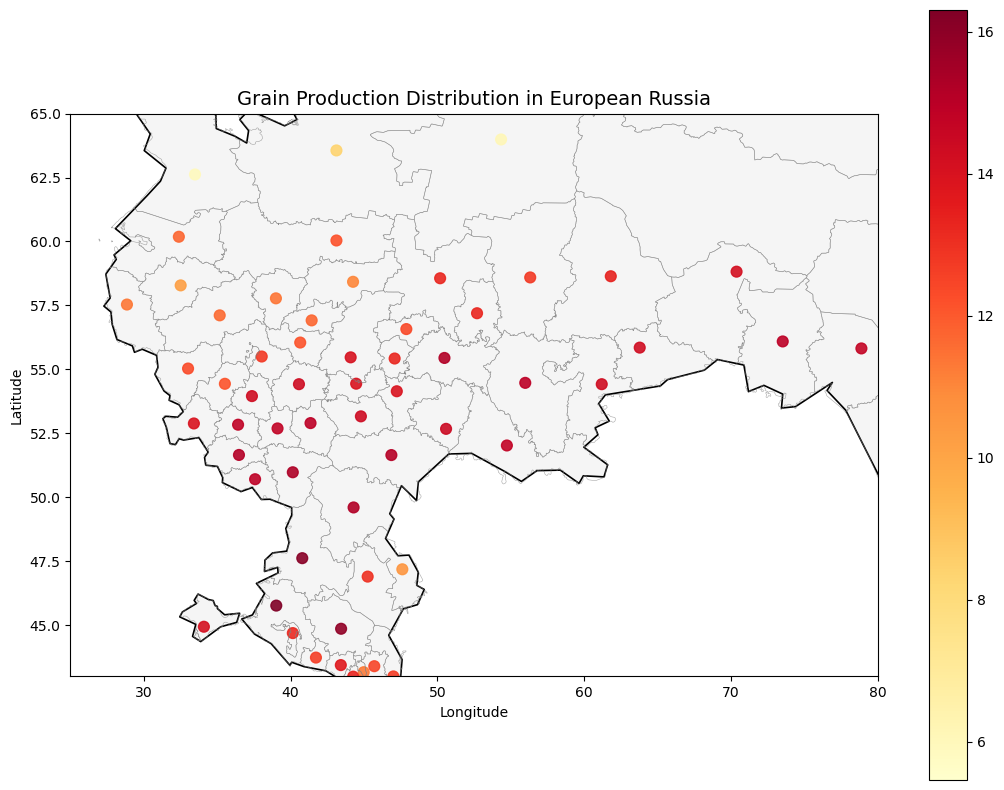

In [79]:
# ===== 1. 数据准备 =====
region_avg = df.groupby("region").agg(
    avg_production=("production", "mean"),
    lat=("lat", "first"),
    lon=("lon", "first")
).reset_index()

region_avg["log_prod"] = np.log(region_avg["avg_production"])

geometry = [Point(xy) for xy in zip(region_avg["lon"], region_avg["lat"])]
gdf_points = gpd.GeoDataFrame(region_avg, geometry=geometry, crs="EPSG:4326")

# ===== 2. 国家边界 =====
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)
russia = world[world["ADMIN"] == "Russia"]

# ===== 3. 行政区边界 =====
admin1 = gpd.read_file("/Users/littlestars/Desktop/grain_project/data/large_files/ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp")

russia_admin1 = admin1[admin1["admin"] == "Russia"]

print("俄罗斯行政区数量：", len(russia_admin1))

# ===== 4. 作图 =====
fig, ax = plt.subplots(figsize=(11, 8))

russia.plot(ax=ax, color="#f5f5f5", edgecolor="black", linewidth=1.2)
russia_admin1.boundary.plot(ax=ax, color="gray", linewidth=0.4, alpha=0.7)

gdf_points.plot(
    ax=ax,
    column="log_prod",
    cmap="YlOrRd",
    markersize=60,
    alpha=0.9,
    legend=True
)

ax.set_xlim(25, 80)
ax.set_ylim(43, 65)

ax.set_title("Grain Production Distribution in European Russia", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()

# 保存到你的项目 figures 文件夹
plt.savefig("/Users/littlestars/Desktop/grain_project/figures/map_european_russia.png",
            dpi=300, bbox_inches="tight")

plt.show()

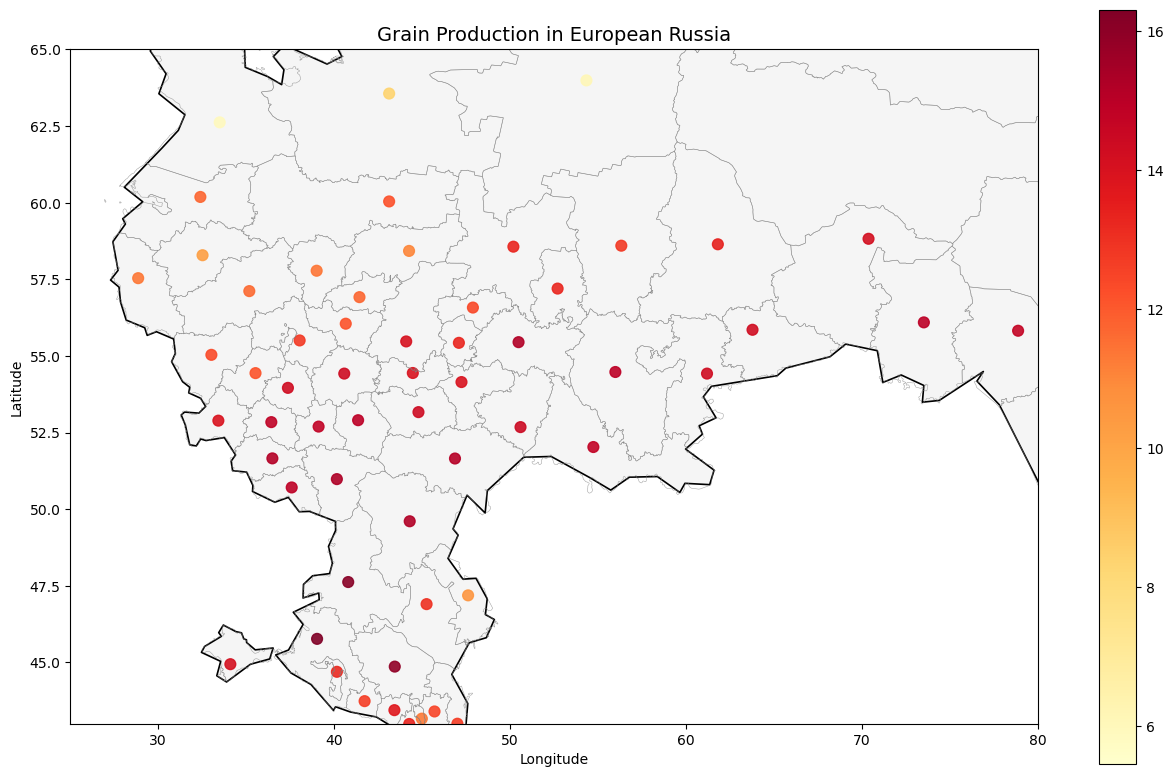

In [81]:
fig, ax = plt.subplots(figsize=(13, 8))

russia.plot(ax=ax, color="#f5f5f5", edgecolor="black", linewidth=1.2)
russia_admin1.boundary.plot(ax=ax, color="gray", linewidth=0.4, alpha=0.7)

gdf_points.plot(
    ax=ax,
    column="log_prod",
    cmap="YlOrRd",
    markersize=60,
    alpha=0.9,
    legend=True
)

# 推荐范围（欧洲俄罗斯）
ax.set_xlim(25, 80)
ax.set_ylim(43, 65)

ax.set_title("Grain Production in European Russia", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()

plt.savefig("/Users/littlestars/Desktop/grain_project/figures/map_european_russia.png",
            dpi=300, bbox_inches="tight")

plt.show()

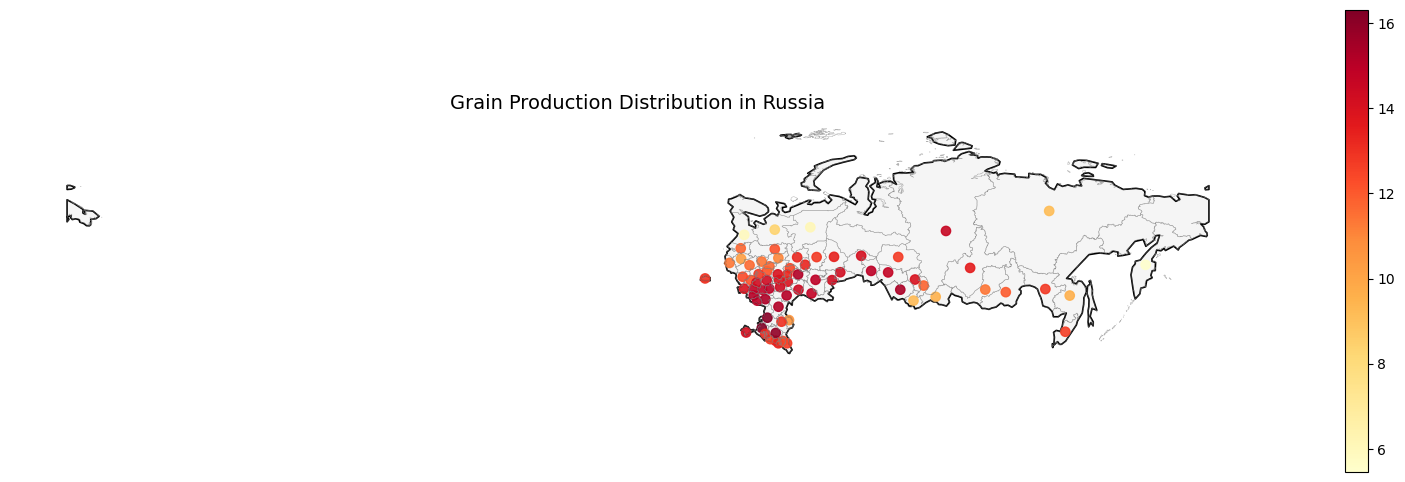

In [83]:
fig, ax = plt.subplots(figsize=(16, 8))


# ===== 作图 =====
russia.plot(ax=ax, color="#f5f5f5", edgecolor="black", linewidth=1.2)
russia_admin1.boundary.plot(ax=ax, color="gray", linewidth=0.35, alpha=0.6)

gdf_points.plot(
    ax=ax,
    column="log_prod",
    cmap="YlOrRd",
    markersize=45,
    alpha=0.9,
    legend=True,
    legend_kwds={"shrink": 0.6}
)

# ===== 自动范围（不要手写经纬度）=====
ax.set_axis_off()

ax.set_title("Grain Production Distribution in Russia", fontsize=14)

plt.tight_layout()

# ===== 规范路径 =====
plt.savefig("/Users/littlestars/Desktop/grain_project/figures/map_european_russia_all.png",
            dpi=300, bbox_inches="tight")

plt.show()
